In [2]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt


In [ ]:
# CARICO PM100 (parquet) -> pandas E STAMPO INFO
# NB Usare job:bes_opt che serve una versione veccha per usare parquet

# import pandas as pd
# pm = pd.read_parquet("datasets/job_table.parquet")
# # Esplora colonne
# print(pm.columns)
# # Aggrega per intervallo temporale (es. resample a 1s/1min)
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end'] = pd.to_datetime(pm['end_time'])
# pm.info()


# example = pm['node_power_consumption'].iloc[1]
# mem = pm['mem_power_consumption'].iloc[1]
# cpu = pm['cpu_power_consumption'].iloc[1]
# print(example)
# print(mem)
# print(cpu)
# len(example)
# duration = (pm['end'] - pm['start']).dt.total_seconds().iloc[1]

# print("samples:", len(example))
# print("duration (s):", duration)
# print("sample interval (s):", duration / len(example))


Index(['cores_alloc_layout', 'cores_allocated', 'cores_per_task', 'derived_ec',
       'eligible_time', 'end_time', 'group_id', 'job_id', 'job_state', 'nodes',
       'num_cores_req', 'num_cores_alloc', 'num_nodes_req', 'num_nodes_alloc',
       'num_tasks', 'partition', 'priority', 'qos', 'req_nodes', 'req_switch',
       'run_time', 'shared', 'start_time', 'state_reason', 'submit_time',
       'threads_per_core', 'time_limit', 'num_gpus_req', 'num_gpus_alloc',
       'mem_req', 'mem_alloc', 'user_id', 'node_power_consumption',
       'mem_power_consumption', 'cpu_power_consumption'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231238 entries, 0 to 231237
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   cores_alloc_layout      231238 non-null  object             
 1   cores_allocated         231238 non-null  object             
 2   cores

In [ ]:
# # DAL PM100 CREO L'ANDAMENTO DELLA POTENZA RICHEISTA DEL CLUSTER SCANDITA OGNI 20 SECONDI
# utilizzando le 3 poerr consumption - non credo abbia senso

# def resample_list(values, N):
#     """Resample a list to length N using linear interpolation.
#        If the list is empty, return zeros."""
#     if len(values) == 0:
#         return np.zeros(N)
#     if len(values) == 1:
#         # se solo 1 valore → replica
#         return np.ones(N) * float(values[0])

#     values = np.array(values, dtype=float)
#     x_old = np.linspace(0, 1, len(values))
#     x_new = np.linspace(0, 1, N)
#     return np.interp(x_new, x_old, values)


# pm = pd.read_parquet("datasets/job_table.parquet")
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end']   = pd.to_datetime(pm['end_time'])

# step = pd.Timedelta(seconds=20)

# rows = []

# for _, row in pm.iterrows():

#     start = row['start']
#     end   = row['end']

#     L_node = len(row['node_power_consumption'])
#     L_mem  = len(row['mem_power_consumption'])
#     L_cpu  = len(row['cpu_power_consumption'])

#     N = max(L_node, L_mem, L_cpu, 1)   # almeno 1

#     node = resample_list(row['node_power_consumption'], N)
#     mem  = resample_list(row['mem_power_consumption'],  N)
#     cpu  = resample_list(row['cpu_power_consumption'],  N)

#     t = pd.date_range(start=start, end=end, periods=N)

#     p = node #+ mem + cpu

#     rows.append(pd.DataFrame({"time": t, "power": p}))

# df_all = pd.concat(rows)

# df_cluster = (
#     df_all
#     .set_index("time")
#     .resample(step)
#     .sum()
# )

# df_cluster.to_csv("cluster_power.csv")
# print(df_cluster.head())



                                 power
time                                  
2020-05-05 15:56:00+00:00  1402.000000
2020-05-05 15:56:20+00:00  1435.934025
2020-05-05 15:56:40+00:00  1496.307886
2020-05-05 15:57:00+00:00     0.000000
2020-05-05 15:57:20+00:00  1559.736098


In [ ]:
# # Stessa cosa di prima ma usando solo i job consumtpion  per node

# def resample_list(values, N):
#     """Resample a list to length N using linear interpolation.
#        If empty → zeros, if length=1 → replicate."""
#     values = list(values)
    
#     if len(values) == 0:
#         return np.zeros(N)
#     if len(values) == 1:
#         return np.ones(N) * float(values[0])

#     values = np.array(values, dtype=float)
#     x_old = np.linspace(0, 1, len(values))
#     x_new = np.linspace(0, 1, N)
#     return np.interp(x_new, x_old, values)

# # Caricamento dataset
# pm = pd.read_parquet("datasets/job_table.parquet")
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end']   = pd.to_datetime(pm['end_time'])

# step = pd.Timedelta(seconds=20)

# rows = []

# for _, row in pm.iterrows():

#     start = row['start']
#     end   = row['end']

#     # Lunghezza della serie node_power_consumption
#     L_node = len(row['node_power_consumption'])

#     # N minimo = max(L_node, 1)
#     N = max(L_node, 1)

#     # 🔥 usa solo node_power_consumption
#     node = resample_list(row['node_power_consumption'], N)

#     # timeline
#     t = pd.date_range(start=start, end=end, periods=N)

#     # DataFrame del job
#     rows.append(pd.DataFrame({"time": t, "power": node}))

# # Unisci tutto
# df_all = pd.concat(rows)

# # Resample cluster
# df_cluster = (
#     df_all
#     .set_index("time")
#     .resample(step)
#     .sum()
# )

# df_cluster.to_csv("cluster_power_only_nodes.csv")

# print(df_cluster.head())


                            power
time                             
2020-05-05 15:56:00+00:00  1280.0
2020-05-05 15:56:20+00:00  1310.0
2020-05-05 15:56:40+00:00  1240.0
2020-05-05 15:57:00+00:00     0.0
2020-05-05 15:57:20+00:00  1280.0


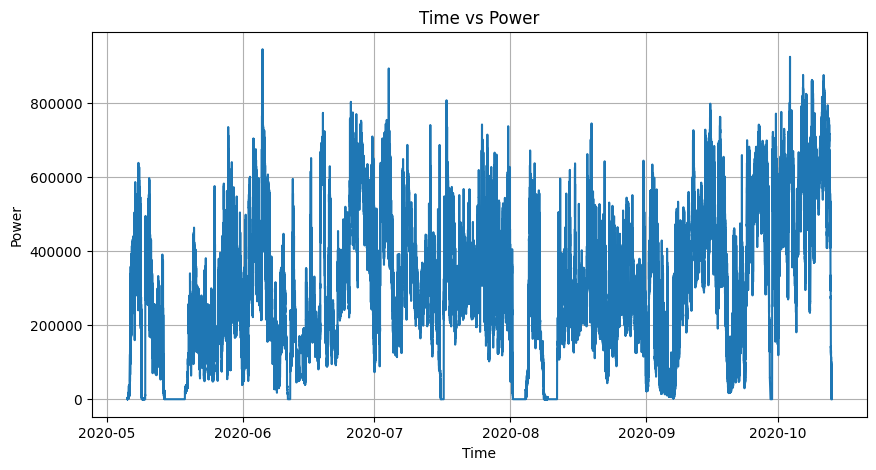

2020-05-05 15:56:00+00:00
2020-10-13 05:21:40+00:00
693618


In [6]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

df = pd.read_csv("csvs/cluster_power_only_nodes.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

print(df["time"][0])
print(df["time"].iloc[-1])
print(len(df)) 
# df_10days.to_csv("cluster_power_only_nodes_30days.csv", index=False)

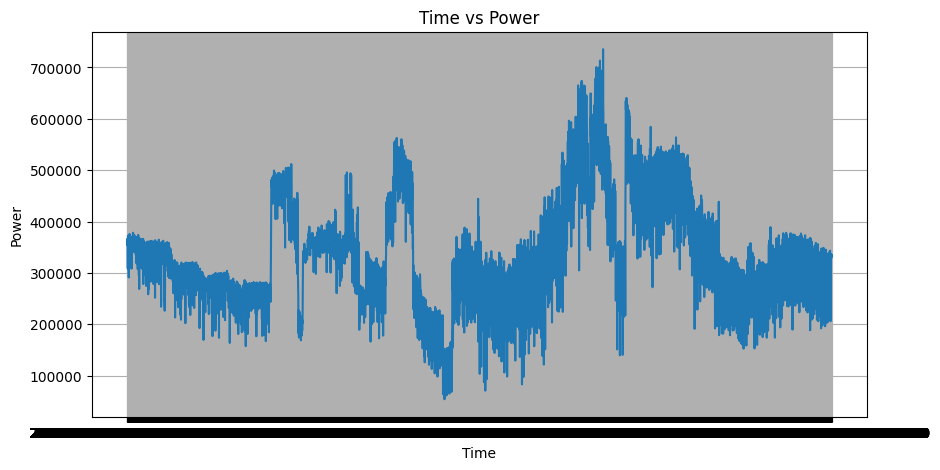

In [1]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
df = pd.read_csv("cluster_power_only_nodes_10days.csv")
df_first = df[8641:12960]
plt.figure(figsize=(10, 5))
plt.plot(df_first["time"], df_first["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

In [ ]:
### simulazione 0 ###

# IN QUESTA SIMULAZIONE, NON ABBIAMO UNA BATTERIA
# valutiamo dunque il costo complessivo senza avere una batteria e avendo una soglia max.
# SE SUPERIAMO LA SOGLIA DI RICHIESTA ALLA RETE ELETTRICA, PAGHIAMO TUTTO DI PIÙ (IL doppio)

import pandas as pd
from utils.co2 import CarbonIntensityModels
from utils.price_model import PriceModel


# Parametri costi
list_thresholds = [200000, 300000,400000,500000]


# Carica il CSV (usa header già presente)
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")#[8641:]
# df = pd.read_csv("cluster_power_only_nodes.csv")

# Inserisco timing
df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

# Inserisco i prezzi
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# INSERISCO VALORI C02
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)

# INSERISCO VALORI C02
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)
# df["co2_intensity"] = cm.co2_fixed(df)


for threshold in list_thresholds:
    # normalizzo
    total_cost = 0
    total_co2 = 0
    for idx, row in df.iterrows():

        COST_LOW = row["price_base"]
        COST_HIGH = row["price_high"]
        CO2_G_PER_KWH = row["co2_intensity"]

        power = row["power"]      # W
        dt = row["dt_hours"]      # h
        t = row["time"]

        if dt <= 0:
            continue

        E_base = min(power, threshold) * dt
        E_peak = max(power - threshold, 0) * dt

        total_cost = total_cost + (E_base * COST_LOW) + (E_peak * COST_HIGH)
        total_co2 = total_co2 +  ((E_base + E_peak) / 1000 * CO2_G_PER_KWH)

        # Risultato finale

    print(" --------------- ")
    print("with threshold = ", threshold)
    print(f"Costo totale: {total_cost:.2f} €")
    print(f"Co2 totale: {total_co2/1000:.2f} Kg Co2")

 --------------- 
with threshold =  200000
Costo totale: 58258.98 €
Co2 totale: 67248.18 Kg Co2
 --------------- 
with threshold =  300000
Costo totale: 50310.71 €
Co2 totale: 67248.18 Kg Co2
 --------------- 
with threshold =  400000
Costo totale: 45901.31 €
Co2 totale: 67248.18 Kg Co2
 --------------- 
with threshold =  500000
Costo totale: 43595.40 €
Co2 totale: 67248.18 Kg Co2


---------------
SIMULAZIONE 1 - BATTERIA PEAK SHAVING
with threshold =  200000
with battery capacity =  1600000
Costo totale con batteria: 59642.40 €
CO2 totale: 69844.281 kg
Carica finale batteria: 167650.13 Wh
SOC finale: 14.97 %
Capacità residua batteria: 1120000.00 Wh
Energia totale caricata in batteria: 10004921.06 Wh
Energia totale scaricata dalla batteria: 9614887.05 Wh
---------------
SIMULAZIONE 1 - BATTERIA PEAK SHAVING
with threshold =  200000
with battery capacity =  3200000
Costo totale con batteria: 59145.30 €
CO2 totale: 69806.081 kg
Carica finale batteria: 376761.90 Wh
SOC finale: 14.97 %
Capacità residua batteria: 2516494.26 Wh
Energia totale caricata in batteria: 13411087.01 Wh
Energia totale scaricata dalla batteria: 13232685.45 Wh
---------------
SIMULAZIONE 1 - BATTERIA PEAK SHAVING
with threshold =  200000
with battery capacity =  6400000
Costo totale con batteria: 58431.95 €
CO2 totale: 69668.855 kg
Carica finale batteria: 832567.64 Wh
SOC finale: 14.97 %
Capacit

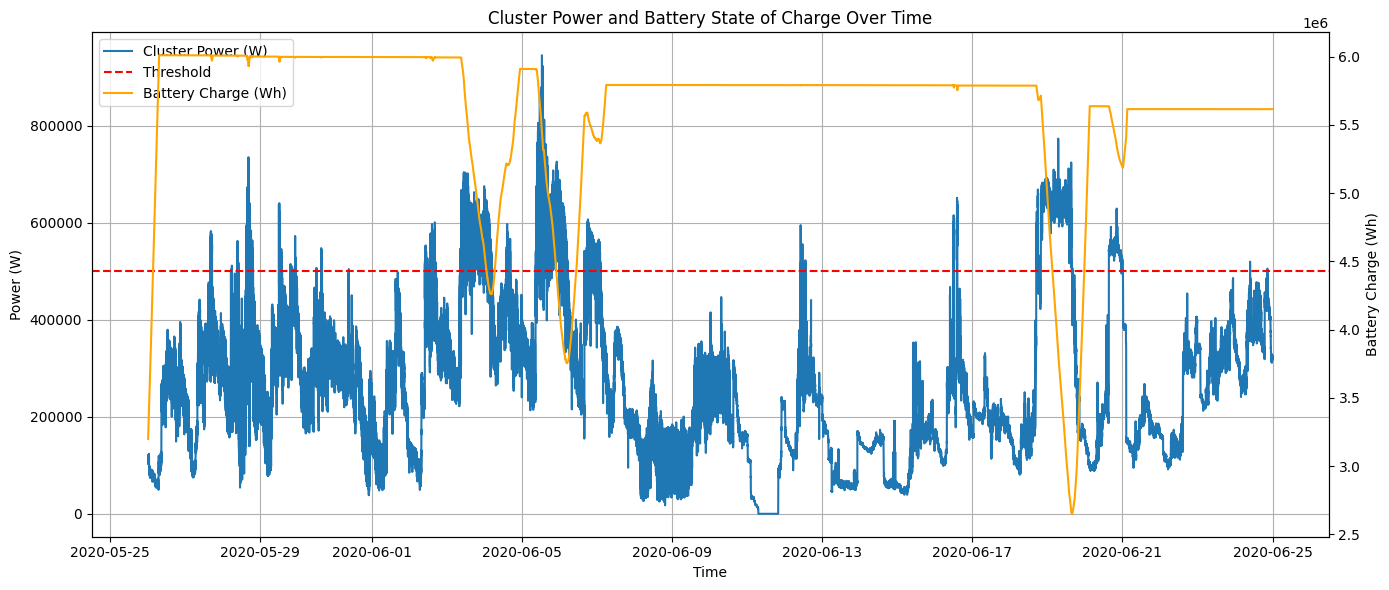

In [ ]:
# SIMULAZIONE 1
# Batteria usata per peak shaving:
# - sopra threshold: scarica per ridurre il picco
# - sotto threshold: si ricarica usando la potenza disponibile sotto soglia
# Non si considera ancora una logica price-aware o carbon-aware.

# inseriti i costi/emissioni in uso batteria e green energy

import pandas as pd
import matplotlib.pyplot as plt
from utils.co2 import CarbonIntensityModels
from utils.battery_model import Battery
from utils.price_model import PriceModel


# ---------------------------
# PARAMETRI
# ---------------------------
list_thresholds = [200000, 300000,400000,500000]
list_battery_capacity = [ 1_600_000, 3_200_000,6_400_000]

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")

df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

# Prezzi
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)

# CO2 intensity
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)

for THRESHOLD in list_thresholds:
    for BATTERY_CAPACITY in list_battery_capacity:

        # ---------------------------
        # INIZIALIZZAZIONE
        # ---------------------------
        battery = Battery(
            capacity_wh=BATTERY_CAPACITY,
            initial_charge_wh=BATTERY_CAPACITY / 2,
            max_charge_rate_w=BATTERY_CAPACITY,
            max_discharge_rate_w=BATTERY_CAPACITY,
        )

        total_cost = 0.0
        total_co2_g = 0.0

        battery_history = []
        time_history = []
        grid_energy_history = []
        battery_charge_energy_history = []
        battery_discharge_energy_history = []
        cost_history = []
        co2_history_g = []

        # ---------------------------
        # SIMULAZIONE
        # ---------------------------
        for _, row in df.iterrows():
            t = row["time"]
            dt = row["dt_hours"]

            if dt <= 0:
                battery_history.append(battery.energy)
                time_history.append(t)
                grid_energy_history.append(0.0)
                battery_charge_energy_history.append(0.0)
                battery_discharge_energy_history.append(0.0)
                cost_history.append(0.0)
                co2_history_g.append(0.0)
                continue

            power = row["power"]                  # W
            cost_low = row["price_base"]          # €/Wh (assunto coerente col tuo modello)
            cost_high = row["price_high"]         # €/Wh
            co2_g_per_kwh = row["co2_intensity"]  # gCO2/kWh

            # Energia richiesta dal cluster
            E_load = power * dt

            # -----------------------------
            # CASO 1: power > threshold
            # Batteria scarica per coprire il picco
            # -----------------------------
            if power > THRESHOLD:
                P_peak_request = power - THRESHOLD

                P_discharge = min(P_peak_request, THRESHOLD)
                E_from_batt = battery.discharge(P_discharge, dt)

                # energia di picco ancora da prendere da rete
                E_peak = max(power - THRESHOLD, 0) * dt
                E_peak_remaining = max(E_peak - E_from_batt, 0.0)

                # quota base da rete
                E_base = THRESHOLD * dt

                # energia totale presa da rete
                E_from_grid = E_base + E_peak_remaining

                cost = E_base * cost_low + E_peak_remaining * cost_high
                co2_g = (E_from_grid / 1000.0) * co2_g_per_kwh

                E_charged = 0.0

                # aggiungo costi e co2 derivanti dall'utilizzo della batteria
                cost = cost + battery.step_cost(dt,  E_from_batt)
                co2_g = co2_g + battery.step_co2_g(dt, E_from_batt)

            # -----------------------------
            # CASO 2: power <= threshold
            # Batteria si carica usando margine sotto soglia
            # -----------------------------
            else:
                E_from_batt = 0.0

                # energia per il carico
                E_base = E_load

                # margine di potenza disponibile sotto soglia
                P_available = THRESHOLD - power
                P_charge = min(P_available, THRESHOLD)

                # energia effettivamente caricata
                E_charged = battery.charge(P_charge, dt)

                # tutta questa energia arriva dalla rete a tariffa base
                E_from_grid = E_base + E_charged

                cost = E_from_grid * cost_low 
                co2_g = (E_from_grid / 1000.0) * co2_g_per_kwh

                # aggiungo costi e co2 derivanti dall'utilizzo della batteria
                cost = cost + battery.step_cost(dt,  E_charged)
                co2_g = co2_g + battery.step_co2_g(dt, E_charged)
                

            # aggiornamento accumulati
            total_cost += cost
            total_co2_g += co2_g

            cost_history.append(cost)
            co2_history_g.append(co2_g)
            grid_energy_history.append(E_from_grid)
            battery_charge_energy_history.append(E_charged)
            battery_discharge_energy_history.append(E_from_batt)

            # dinamica lenta batteria
            battery.step(dt)

            # salvo stato dopo lo step
            battery_history.append(battery.energy)
            time_history.append(t)


        # ---------------------------
        # RISULTATI FINALI
        # ---------------------------
        print("---------------")
        print("SIMULAZIONE 1 - BATTERIA PEAK SHAVING")
        print("with threshold = ", THRESHOLD)
        print("with battery capacity = ", BATTERY_CAPACITY)
        print(f"Costo totale con batteria: {total_cost:.2f} €")
        print(f"CO2 totale: {total_co2_g / 1000:.3f} kg")
        print(f"Carica finale batteria: {battery.energy:.2f} Wh")
        print(f"SOC finale: {battery.soc * 100:.2f} %")
        print(f"Capacità residua batteria: {battery.capacity:.2f} Wh")
        print(f"Energia totale caricata in batteria: {sum(battery_charge_energy_history):.2f} Wh")
        print(f"Energia totale scaricata dalla batteria: {sum(battery_discharge_energy_history):.2f} Wh")


# ---------------------------
# GRAFICO
# ---------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.axhline(THRESHOLD, color="red", linestyle="--", label="Threshold")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

plt.title("Cluster Power and Battery State of Charge Over Time")

lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()

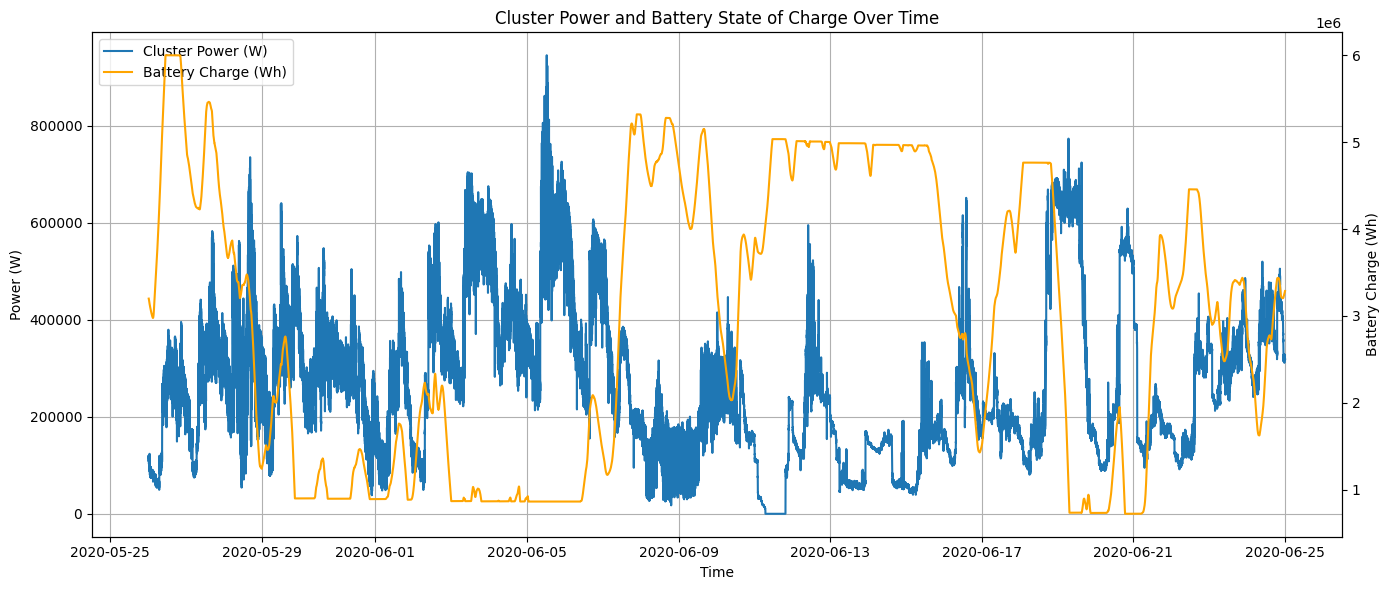

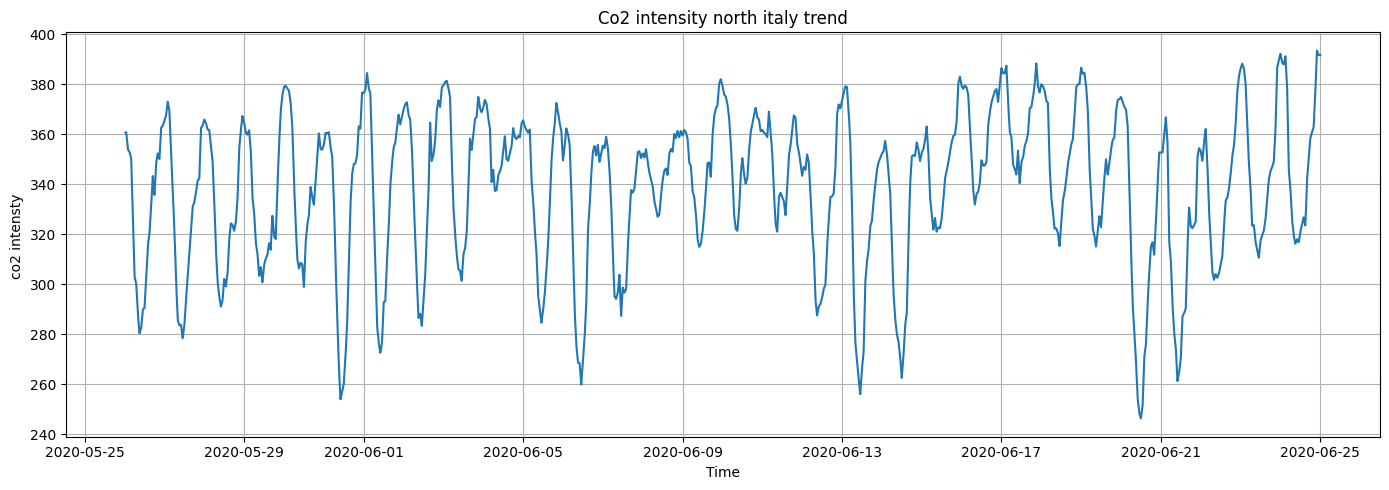

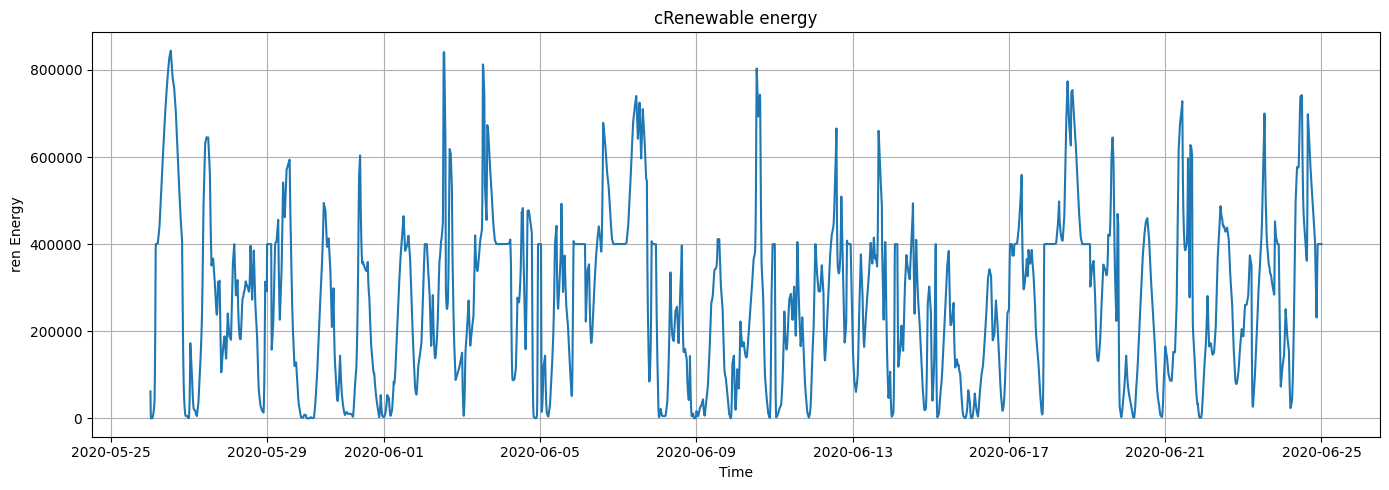

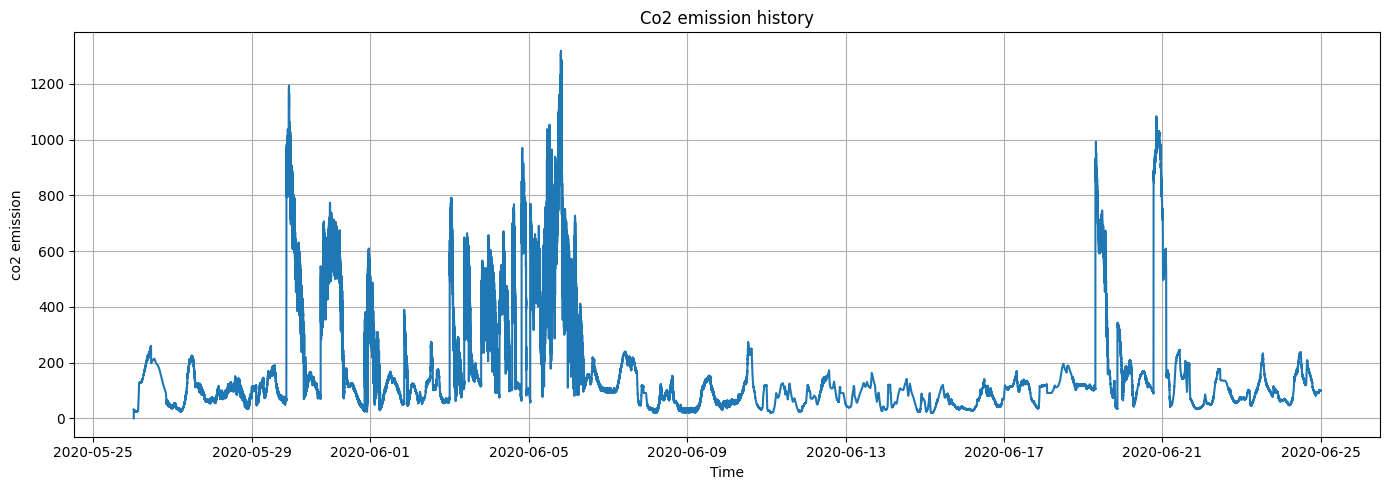

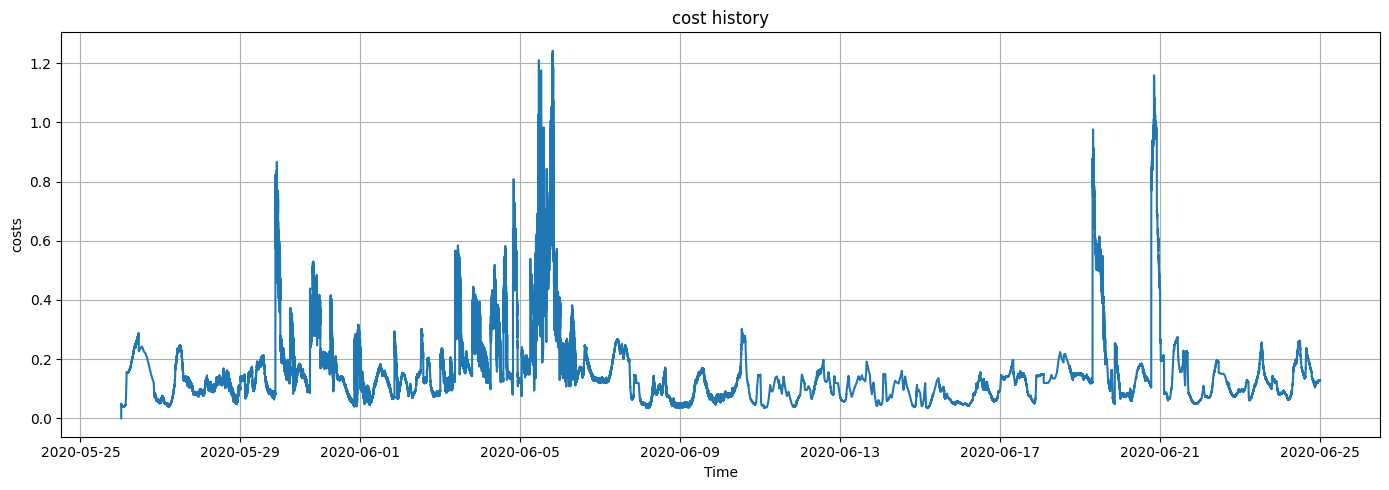

In [ ]:
####       SIMULAZIONE 2      #####

# In questa simulazione abbiamo la batteria che viene utilizzata come 
# Accumulatore di energie rinnoviabili.
# Vengono unsate tutte le rinnovabili possibili e se ce n'è un eccesso, 
# si ricarica l'accumulatore.
# Se le rinnovabili non bastano, si usa prima la batteria e poi la rete elettrica.

# Vengono aggiunti prezzi ed emisioni sia per l'utilizzo della batteria, sia per 
# ogni kwh prodotti dallla green energy, anche quelli curtailment.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils.renewable_real import RenewableModels
from utils.co2 import CarbonIntensityModels
from utils.carbonENTSOE import CarbonIntensityENTSOE
from utils.battery_model import Battery
from utils.price_model import PriceModel



## LOAD DATASET 
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv") #[8641:]
# df = pd.read_csv("cluster_power_only_nodes.csv")

df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

# INSERISCO PREZZI
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)

# ---------------------------
# PARAMETRI COSTI / CO2 GREEN
# ---------------------------
SOLAR_COST_EUR_PER_KWH = 0.05
WIND_COST_EUR_PER_KWH  = 0.04

SOLAR_CO2_G_PER_KWH = 50.0
WIND_CO2_G_PER_KWH  = 34.0

# ---------------------------
# PARAMETRI
# ---------------------------

THRESHOLD = 400000          # W
BATTERY_CAPACITY = 3_200_000      # Wh

# list_thresholds = [300000,400000,500000]
# list_battery_capacity = [800_000, 1_600_000, 3_200_000,6_400_000]
# list_renewables = [(200000,250000),(300000,350000),(400000,450000)]

list_thresholds = [200000, 400000]
list_battery_capacity = [ 1_600_000, 3_200_000,6_400_000]
list_renewables = [(200000,250000),(400000,450000)]

# list_thresholds = [250000]
# list_battery_capacity = [3_200_000]
# list_renewables = [(300000,350000)]


results = []

for THRESHOLD in list_thresholds :
    for BATTERY_CAPACITY in list_battery_capacity:
        for p_max_ren in list_renewables:


            battery = Battery(
                capacity_wh=BATTERY_CAPACITY,
                initial_charge_wh=BATTERY_CAPACITY / 2,
                max_charge_rate_w=BATTERY_CAPACITY,
                max_discharge_rate_w=BATTERY_CAPACITY,
            )


            total_cost = 0
            total_co2_g = 0

            battery_history = []
            time_history = []
            curtailment_history = []
            cost_history = []
            co2_history_g = []



            # INSERISCO VALORI RINNOVABILI
            rm = RenewableModels()   # seed diverso per trainin
            df["P_wind"] = rm.wind_from_openmeteo(df, p_max_ren[0])
            df["P_solar"] = rm.solar_from_openmeteo(df, p_max_ren[1])
            df["P_ren"]   = df["P_solar"] + df["P_wind"]

            # INSERISCO VALORI C02
            cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
            df["co2_intensity"] = cm.co2_from_csv(df)


            # cm =CarbonIntensityENTSOE(api_key="---")
            # df["co2_intensity"] = cm.co2_from_entsoe(df)

            # df["energy_Wh"] = df["power"] * df["dt_hours"]

            # ASSUNZIONE: MAX_CHARGE_RATE, MAX_DISCHARGE_RATE in W; BATTERY_* in Wh; dt in hours
            # THRESHOLD in W si applica alla POTENZA presa dalla rete (P_grid)

            # per sapere dove sto spendendo
            sum_E_green_total_Wh = 0.0
            sum_green_cost = 0.0
            sum_green_co2_g = 0.0
            sum_batt_cost = 0.0
            sum_batt_co2_g = 0.0
            sum_grid_cost = 0.0
            sum_grid_co2_g = 0.0

            for idx, row in df.iterrows():
                COST_LOW = row["price_base"]
                COST_HIGH = row["price_high"]
                CO2_G_PER_KWH_GRID = row["co2_intensity"]

                P_load = row["power"]
                P_wind = row["P_wind"]
                P_solar = row["P_solar"]
                P_ren = row["P_ren"]
                dt = row["dt_hours"]
                t = row["time"]

                if dt <= 0:
                    battery_history.append(battery.energy)
                    time_history.append(t)
                    curtailment_history.append(0.0)
                    cost_history.append(0.0)
                    co2_history_g.append(0.0)
                    continue

                # ---------------------------
                # GREEN: energia totale prodotta
                # ---------------------------
                E_wind_total = P_wind * dt
                E_solar_total = P_solar * dt
                E_green_total = E_wind_total + E_solar_total

                green_cost = (
                    (E_wind_total / 1000.0) * WIND_COST_EUR_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_COST_EUR_PER_KWH
                )

                green_co2_g = (
                    (E_wind_total / 1000.0) * WIND_CO2_G_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_CO2_G_PER_KWH
                )

                sum_E_green_total_Wh += E_green_total
                sum_green_cost += green_cost
                sum_green_co2_g += green_co2_g

                # inizializzazione
                E_charged = 0.0
                E_from_batt = 0.0
                E_curtail = 0.0
                grid_cost = 0.0
                grid_co2_g = 0.0

                # uso rinnovabili
                P_from_ren = min(P_load, P_ren)
                P_excess_ren = max(P_ren - P_from_ren, 0.0)

                # surplus -> batteria
                if P_excess_ren > 0:
                    E_excess_available = P_excess_ren * dt
                    E_charged = battery.charge(P_excess_ren, dt)
                    E_curtail = max(E_excess_available - E_charged, 0.0)

                # deficit -> batteria -> rete
                else:
                    P_remaining = P_load - P_from_ren
                    E_needed = P_remaining * dt

                    E_from_batt = battery.discharge(P_remaining, dt)
                    E_needed_after_batt = max(E_needed - E_from_batt, 0.0)

                    P_grid_import = E_needed_after_batt / dt if dt > 0 else 0.0

                    E_base = min(P_grid_import, THRESHOLD) * dt
                    E_peak = max(P_grid_import - THRESHOLD, 0.0) * dt
                    E_from_grid = E_base + E_peak

                    grid_cost = E_base * COST_LOW + E_peak * COST_HIGH
                    grid_co2_g = (E_from_grid / 1000.0) * CO2_G_PER_KWH_GRID

                sum_grid_cost += grid_cost
                sum_grid_co2_g += grid_co2_g

                # batteria
                E_batt_throughput = E_charged + E_from_batt
                batt_cost = battery.step_cost(dt, E_batt_throughput)
                batt_co2_g = battery.step_co2_g(dt, E_batt_throughput)

                sum_batt_cost += batt_cost
                sum_batt_co2_g += batt_co2_g

                # totale step
                step_cost = green_cost + grid_cost + batt_cost
                step_co2_g = green_co2_g + grid_co2_g + batt_co2_g

                total_cost += step_cost
                total_co2_g += step_co2_g

                cost_history.append(step_cost)
                co2_history_g.append(step_co2_g)
                curtailment_history.append(E_curtail)

                battery.step(dt)

                battery_history.append(battery.energy)
                time_history.append(t)

            info = battery.info()
            results.append({
                "threshold": THRESHOLD,
                "battery_capacity": BATTERY_CAPACITY,
                "pmaxwind": p_max_ren[0],
                "pmaxsun": p_max_ren[1],
                "costo_euro": round(total_cost,3),
                "co2_kg": round(total_co2_g / 1000,3),
                "SOC_finale": round(info["SOC"],3),
                "capacity_ratio": round(info["capacity_Wh"] / BATTERY_CAPACITY,3),
                "sum_curtailment": round(sum(curtailment_history),3),
                "battery_history": round(sum(battery_history),3),
                "E_green_total_Wh": round(df["P_ren"].mul(df["dt_hours"]).sum(), 3),
                "green_cost_total_euro": round(sum_green_cost, 3),
                "green_co2_total_kg": round(sum_green_co2_g / 1000, 3),
                "battery_cost_total_euro": round(sum_batt_cost, 3),
                "battery_co2_total_kg": round(sum_batt_co2_g / 1000, 3),
                "grid_cost_total_euro": round(sum_grid_cost, 3),
                "grid_co2_total_kg": round(sum_grid_co2_g / 1000, 3)
            })

# salvo i results su file
pd.DataFrame(results).to_csv("outputSim/results.csv", index=False)

fig, ax1 = plt.subplots(figsize=(14, 6))
# ---- Grafico della potenza (asse sinistro) ----
ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

# ---- Asse destro per la carica della batteria ----
ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

# ---- Titolo e legende ----
plt.title("Cluster Power and Battery State of Charge Over Time")

# Legende combinate
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["co2_intensity"])
plt.xlabel("Time")
plt.ylabel("co2 intensty ")
plt.title("Co2 intensity north italy trend")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["P_ren"])
plt.xlabel("Time")
plt.ylabel("ren Energy")
plt.title("cRenewable energy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, co2_history_g)
plt.xlabel("Time")
plt.ylabel("co2 emission")
plt.title("Co2 emission history")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, cost_history)
plt.xlabel("Time")
plt.ylabel("costs")
plt.title("cost history")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# test saved model

obs, _ = env.reset()
done = False
total_cost_rl = 0

while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_cost_rl += -reward

print("Costo totale RL:", total_cost_rl)

In [8]:
####       SIMULAZIONE 3      #####
# In questa simulazione abbiamo la batteria che viene utilizzata come
# accumulatore di energie rinnovabili.
#
# Logica:
# 1) uso tutta la rinnovabile disponibile per coprire il carico
# 2) se la rinnovabile eccede il carico, carico la batteria
# 3) se la rinnovabile non basta, uso la batteria
# 4) se non basta ancora:
#       - sotto soglia uso la rete
#       - sopra soglia uso il generatore e/o la rete
#
# Qui vengono anche considerati:
# - costo/CO2 della batteria
# - costo/CO2 della green energy
# - costo/CO2 della rete
# - costo/CO2 del generatore


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from utils.renewable_real import RenewableModels
from utils.co2 import CarbonIntensityModels
from utils.carbonENTSOE import CarbonIntensityENTSOE
from utils.battery_model import Battery
from utils.generator_model import Generator
from utils.price_model import PriceModel


# ---------------------------
# LOAD DATASET
# ---------------------------
df = pd.read_csv("csvs/cluster_power_only_nodes_30days.csv")
# df = pd.read_csv("cluster_power_only_nodes.csv")

df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

# INSERISCO PREZZI
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# ---------------------------
# PARAMETRI
# ---------------------------

# list_thresholds = [200000, 300000, 400000, 500000]
# list_battery_capacity = [800_000, 1_600_000, 3_200_000, 6_400_000]
# list_renewables = [(200000,250000), (300000,350000), (400000,450000)]

list_thresholds = [200000, 400000]
list_battery_capacity = [1_600_000, 3_200_000, 6_400_000]
list_renewables = [(200000, 250000), (400000, 450000)]

# list_thresholds = [250000]
# list_battery_capacity = [3_200_000]
# list_renewables = [(300000,350000)]


# ---------------------------
# PARAMETRI GREEN ENERGY
# Costo levelized / lifecycle semplificato
# ---------------------------
SOLAR_COST_EUR_PER_KWH = 0.05
WIND_COST_EUR_PER_KWH  = 0.04

SOLAR_CO2_G_PER_KWH = 50.0
WIND_CO2_G_PER_KWH  = 34.0


results = []

for THRESHOLD in list_thresholds:
    for BATTERY_CAPACITY in list_battery_capacity:
        for p_max_ren in list_renewables:

            # ---------------------------
            # BATTERIA
            # ---------------------------
            battery = Battery(
                capacity_wh=BATTERY_CAPACITY,
                initial_charge_wh=BATTERY_CAPACITY / 2,
                max_charge_rate_w=BATTERY_CAPACITY,
                max_discharge_rate_w=BATTERY_CAPACITY,
            )

            # ---------------------------
            # GENERATORE
            # ---------------------------
            generator = Generator(
                max_power_w=500000,
                min_power_w=50000,
                efficiency=0.4,
                fuel_cost_per_wh=0.00025,
                co2_g_per_kwh=450
            )

            # ---------------------------
            # TOTALI
            # ---------------------------
            total_cost = 0.0
            total_co2_g = 0.0

            # breakdown energia/costo/co2
            sum_E_green_total_Wh = 0.0
            sum_green_cost = 0.0
            sum_green_co2_g = 0.0

            sum_batt_cost = 0.0
            sum_batt_co2_g = 0.0

            sum_grid_cost = 0.0
            sum_grid_co2_g = 0.0

            sum_gen_cost = 0.0
            sum_gen_co2_g = 0.0

            sum_E_from_grid = 0.0
            sum_E_from_gen = 0.0
            sum_E_from_batt = 0.0
            sum_E_batt_charged = 0.0

            # storico
            battery_history = []
            time_history = []
            curtailment_history = []
            cost_history = []
            gen_use_history = []
            battery_use_history = []
            co2_history_g = []

            # ---------------------------
            # INSERISCO VALORI RINNOVABILI
            # ---------------------------
            rm = RenewableModels()
            df["P_wind"] = rm.wind_from_openmeteo(df, p_max_ren[0])
            df["P_solar"] = rm.solar_from_openmeteo(df, p_max_ren[1])
            df["P_ren"] = df["P_solar"] + df["P_wind"]

            # ---------------------------
            # INSERISCO VALORI CO2 GRID
            # ---------------------------
            cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
            df["co2_intensity"] = cm.co2_from_csv(df)

            # cm = CarbonIntensityENTSOE(api_key="---")
            # df["co2_intensity"] = cm.co2_from_entsoe(df)

            for idx, row in df.iterrows():
                COST_LOW = row["price_base"]
                COST_HIGH = row["price_high"]
                CO2_G_PER_KWH_GRID = row["co2_intensity"]

                P_load = row["power"]       # W
                P_wind = row["P_wind"]      # W
                P_solar = row["P_solar"]    # W
                P_ren = row["P_ren"]        # W
                dt = row["dt_hours"]        # h
                t = row["time"]

                if dt <= 0:
                    battery_history.append(battery.energy)
                    time_history.append(t)
                    curtailment_history.append(0.0)
                    cost_history.append(0.0)
                    co2_history_g.append(0.0)
                    gen_use_history.append(0.0)
                    battery_use_history.append(0.0)
                    continue

                # ==================================================
                # 0) COSTO / CO2 DELLA GREEN ENERGY
                # Qui li imputiamo sulla produzione totale
                # ==================================================
                E_wind_total = P_wind * dt
                E_solar_total = P_solar * dt
                E_green_total = E_wind_total + E_solar_total

                green_cost = (
                    (E_wind_total / 1000.0) * WIND_COST_EUR_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_COST_EUR_PER_KWH
                )

                green_co2_g = (
                    (E_wind_total / 1000.0) * WIND_CO2_G_PER_KWH +
                    (E_solar_total / 1000.0) * SOLAR_CO2_G_PER_KWH
                )

                sum_E_green_total_Wh += E_green_total
                sum_green_cost += green_cost
                sum_green_co2_g += green_co2_g

                # inizializzazione contributi step
                E_charged = 0.0
                E_from_batt = 0.0
                E_curtail = 0.0

                E_from_gen = 0.0
                E_from_grid = 0.0

                cost_grid = 0.0
                cost_gen = 0.0
                co2_grid = 0.0
                co2_gen = 0.0

                # ==================================================
                # 1) uso rinnovabili per coprire il carico
                # ==================================================
                P_from_ren = min(P_load, P_ren)
                P_excess_ren = max(P_ren - P_from_ren, 0.0)

                # ==================================================
                # 1a) surplus rinnovabile -> batteria
                # ==================================================
                if P_excess_ren > 0:
                    E_excess_available = P_excess_ren * dt
                    E_charged = battery.charge(P_excess_ren, dt)
                    E_curtail = max(E_excess_available - E_charged, 0.0)

                else:
                    # ==================================================
                    # 2) deficit -> batteria
                    # ==================================================
                    P_remaining = P_load - P_from_ren
                    E_needed = P_remaining * dt

                    E_from_batt = battery.discharge(P_remaining, dt)
                    E_needed_after_batt = max(E_needed - E_from_batt, 0.0)

                    P_after_batt = E_needed_after_batt / dt if dt > 0 else 0.0

                    # ==================================================
                    # 3) GRID + GENERATOR POLICY
                    # ==================================================

                    # OPZ1: generatore solo se conviene per il prezzo
                    # (soft constraint, economic dispatch semplificato)
                    # use_generator = COST_HIGH > generator.fuel_cost_per_wh

                    # OPZ2: generatore sempre quando si supera threshold
                    # (hard constraint)
                    use_generator = 1

                    # quota sotto soglia -> rete
                    P_grid_base = min(P_after_batt, THRESHOLD)

                    # quota sopra soglia -> peak
                    P_peak = max(P_after_batt - THRESHOLD, 0.0)

                    # generatore limitato dalla potenza massima
                    if use_generator:
                        P_gen = min(P_peak, generator.max_power_w)
                    else:
                        P_gen = 0.0

                    # eventuale extra torna alla rete
                    P_grid_peak = P_peak - P_gen

                    # totale rete
                    P_grid = P_grid_base + P_grid_peak

                    # energie
                    E_from_gen = P_gen * dt
                    E_from_grid = P_grid * dt

                    E_base = P_grid_base * dt
                    E_peak = P_grid_peak * dt

                    # costi rete
                    cost_grid = E_base * COST_LOW + E_peak * COST_HIGH

                    # costi generatore
                    cost_gen = generator.get_cost(E_from_gen)

                    # co2 rete
                    co2_grid = (E_from_grid / 1000.0) * CO2_G_PER_KWH_GRID

                    # co2 generatore
                    co2_gen = generator.get_co2(E_from_gen / 1000.0)

                # ==================================================
                # 4) COSTO / CO2 BATTERIA
                # throughput = carica + scarica
                # ==================================================
                E_batt_throughput = E_charged + E_from_batt

                batt_cost = battery.step_cost(dt, E_batt_throughput)
                batt_co2_g = battery.step_co2_g(dt, E_batt_throughput)

                sum_batt_cost += batt_cost
                sum_batt_co2_g += batt_co2_g

                # breakdown generator / grid
                sum_grid_cost += cost_grid
                sum_grid_co2_g += co2_grid
                sum_gen_cost += cost_gen
                sum_gen_co2_g += co2_gen

                sum_E_from_grid += E_from_grid
                sum_E_from_gen += E_from_gen
                sum_E_from_batt += E_from_batt
                sum_E_batt_charged += E_charged

                # ==================================================
                # 5) TOTALI STEP
                # ==================================================
                step_cost = green_cost + batt_cost + cost_grid + cost_gen
                step_co2_g = green_co2_g + batt_co2_g + co2_grid + co2_gen

                total_cost += step_cost
                total_co2_g += step_co2_g

                # storico
                curtailment_history.append(E_curtail)
                cost_history.append(step_cost)
                co2_history_g.append(step_co2_g)

                battery_history.append(battery.energy)
                time_history.append(t)
                gen_use_history.append(E_from_gen)
                battery_use_history.append(E_from_batt)

                battery.step(dt)

            info = battery.info()

            results.append({
                "threshold": THRESHOLD,
                "battery_capacity": BATTERY_CAPACITY,
                "pmaxwind": p_max_ren[0],
                "pmaxsun": p_max_ren[1],

                "costo_euro": round(total_cost, 3),
                "co2_kg": round(total_co2_g / 1000.0, 3),

                "green_energy_total_Wh": round(sum_E_green_total_Wh, 3),
                "green_cost_total_euro": round(sum_green_cost, 3),
                "green_co2_total_kg": round(sum_green_co2_g / 1000.0, 3),

                "battery_cost_total_euro": round(sum_batt_cost, 3),
                "battery_co2_total_kg": round(sum_batt_co2_g / 1000.0, 3),

                "grid_cost_total_euro": round(sum_grid_cost, 3),
                "grid_co2_total_kg": round(sum_grid_co2_g / 1000.0, 3),

                "generator_cost_total_euro": round(sum_gen_cost, 3),
                "generator_co2_total_kg": round(sum_gen_co2_g / 1000.0, 3),

                "E_from_grid_Wh": round(sum_E_from_grid, 3),
                "E_from_gen_Wh": round(sum_E_from_gen, 3),
                "E_from_batt_Wh": round(sum_E_from_batt, 3),
                "E_to_batt_Wh": round(sum_E_batt_charged, 3),

                "SOC_finale": round(info["SOC"], 3),
                "capacity_ratio": round(info["capacity_Wh"] / BATTERY_CAPACITY, 3),

                "sum_curtailment_Wh": round(sum(curtailment_history), 3),
                "battery_use_history_Wh": round(sum(battery_use_history), 3),
                "gen_use_history_Wh": round(sum(gen_use_history), 3),
            })

# salvo i risultati
pd.DataFrame(results).to_csv("outputSim/results_battandgen_HC.csv", index=False)

## altre idee:

0) inserire capex -> soldi del costo iniziale della batteria/energia green/generatore spalmati nel tempo.

      - valutare, quando inizia ad aver senso inserire una batteria o green o gen
      - anche la green inizierebbe ad avere un costo! quindi scelta per RL
         (il costo della green andrebbe per tempo di utilizzo, non di KW effettivamente
         prodotto, in questo caso a volte conviene a volte no)


1) aumenatare la richiesta del cluster fino a 5 - 20 MW
2) aumentare il tempo di richiesta, da 10 gg a 100 gg
 
3) inserire costi/ritardi accensione generatore
      - impatto sul duperamento del limite threshold, se ci mette un po ad accendersi, per un po sarà superata.. ( RL potrebbe prevedere la cosa..)
      - accensione non gratis, se accendo conviene mantenerlo acceso e continuare ad usarlo?
4) inserire la modalità acceso/spento ma non usato al generatore, cosi da non doverlo riaccenderlo ogni volta, ovviamente un po continua a consumare..
5) Valutare se rendere la threshold soft constraint. 2 trheshold: 1 per costo 1 per limite rete elettrica.
6) inserire picchi di prezzo nel costo della rete elettrica(?)     

## Blackout: 
 simulare sbalzi di corrente e/o blackout e fare in modo che il cluster possa andare avanti come nulla fosse 
 Una batteria in piu? tenere una parte della batteria sempre disponibile?
 in RL si può implementare nel "temrina partita" se non c'è energia per questo
 https://www.researchgate.net/profile/Gideon-Areo/publication/389673817_Fault-Tolerant_Strategies_for_Parallel_Computing_in_Large-Scale_HPC_Systems/links/67cc046b7c5b5569dcb8479b/Fault-Tolerant-Strategies-for-Parallel-Computing-in-Large-Scale-HPC-Systems.pdf
 
  
## Cooling: 
 si può inserire l'idea che oltre al consumo dei nodi si oncidera il consumo del raffreddanemto che oscilla
tra il 30 e il 50% del consumo nodi.
Questo si può rendere meno prevedibile e si può usare il generatore per gestire il cooling 
 